# Analysis of LEK Dataset
This notebook performs a series of analyses to explore, preprocess, and model the data related to "Clove.Benefit.Score." The steps include feature selection, correlation analysis, multicollinearity check, model building, and interpretation using permutation importance and SHAP values.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import chi2
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the sociodemographic dataset
data_socio = pd.read_csv(r'C:\Users\yazda\Desktop\AyeAye2024\Aye-Aye-Project\data\Benefit_sociodemographic_data.csv', delimiter=';')

# Load the binary dataset
data_binary = pd.read_csv(r'C:\Users\yazda\Desktop\AyeAye2024\Aye-Aye-Project\data\Benefit_Knowledge_data.csv', delimiter=';')
print(data_binary.columns)
print(data_socio.columns)
merged_data = pd.concat([data_binary, data_socio], axis=1)
merged_data.shape
merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]

# Display the columns to confirm the removal
print(merged_data.columns)

Index(['Clove.benefit.score', 'ID.nom', 'ID.vis.Aye', 'Other.lemurs',
       'Diet.Insects', 'Knowledge.signs', 'Knowledge.Abundance',
       'Activity.knowledge', 'Weight.knowledge', 'Lifestyle.knowledge',
       'Lemur.knowledge', 'Aye.aye.protected', 'encountered.binary'],
      dtype='object')
Index(['Clove.benefit.score', 'Region', 'Remoteness', 'village.size', 'School',
       'Forest.cover2017', 'Forest.cover1990', 'Gender', 'Agegroup',
       'edu.level', 'Ethnic.group', 'Migration.Experience', 'Farms.Cloves',
       'Farms.Paddy.Rice', 'Farms.Tavy.Rice', 'Extracts.Medical.plants'],
      dtype='object')
Index(['Clove.benefit.score', 'ID.nom', 'ID.vis.Aye', 'Other.lemurs',
       'Diet.Insects', 'Knowledge.signs', 'Knowledge.Abundance',
       'Activity.knowledge', 'Weight.knowledge', 'Lifestyle.knowledge',
       'Lemur.knowledge', 'Aye.aye.protected', 'encountered.binary', 'Region',
       'Remoteness', 'village.size', 'School', 'Forest.cover2017',
       'Forest.cover1990', 

In [3]:
# Data Preprocessing for Merged Data
# Encode categorical variables in the merged dataset
label_encoders = {}
for column in merged_data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    merged_data[column] = le.fit_transform(merged_data[column])
    label_encoders[column] = le

# Standardize numerical features in the merged dataset
# scaler = StandardScaler()
# numeric_columns = merged_data.select_dtypes(include=['int64', 'float64']).columns
# merged_data[numeric_columns] = scaler.fit_transform(merged_data[numeric_columns])

# Split merged data into features and target
X_merged = merged_data.drop('Clove.benefit.score', axis=1)
y_merged = merged_data['Clove.benefit.score']
X_train_merged, X_test_merged, y_train_merged, y_test_merged = train_test_split(X_merged, y_merged, test_size=0.3, random_state=42)


In [4]:
# Preprocessing Function with One-Hot Encoding
def preprocess_data_with_one_hot_encoding(data):
    # Drop unnecessary columns
    data.drop(['Forest.cover2017', 'Forest.cover1990'], axis=1, inplace=True)

    # Handle missing values and encode educational level
    data['edu.level'] = data['edu.level'].fillna('NoEducation')
    data['edu.level'] = data['edu.level'].replace({'NoEducation': '1', 'Primary': '2', 'Secondary': '3', 'High': '4'})

    # Exclude the target column from one-hot encoding
    if 'Clove.benefit.score' in data.columns:
        target = data['Clove.benefit.score']
        data.drop('Clove.benefit.score', axis=1, inplace=True)
    
    # One-hot encoding for categorical variables
    data = pd.get_dummies(data, columns=['Gender', 'Region', 'Agegroup', 'edu.level'], 
                          drop_first=True, 
                          dtype=int,
                          prefix_sep='_')
    
    return data, target

# Preprocess the merged dataset
X_merged_encoded, y_merged_encoded = preprocess_data_with_one_hot_encoding(merged_data)


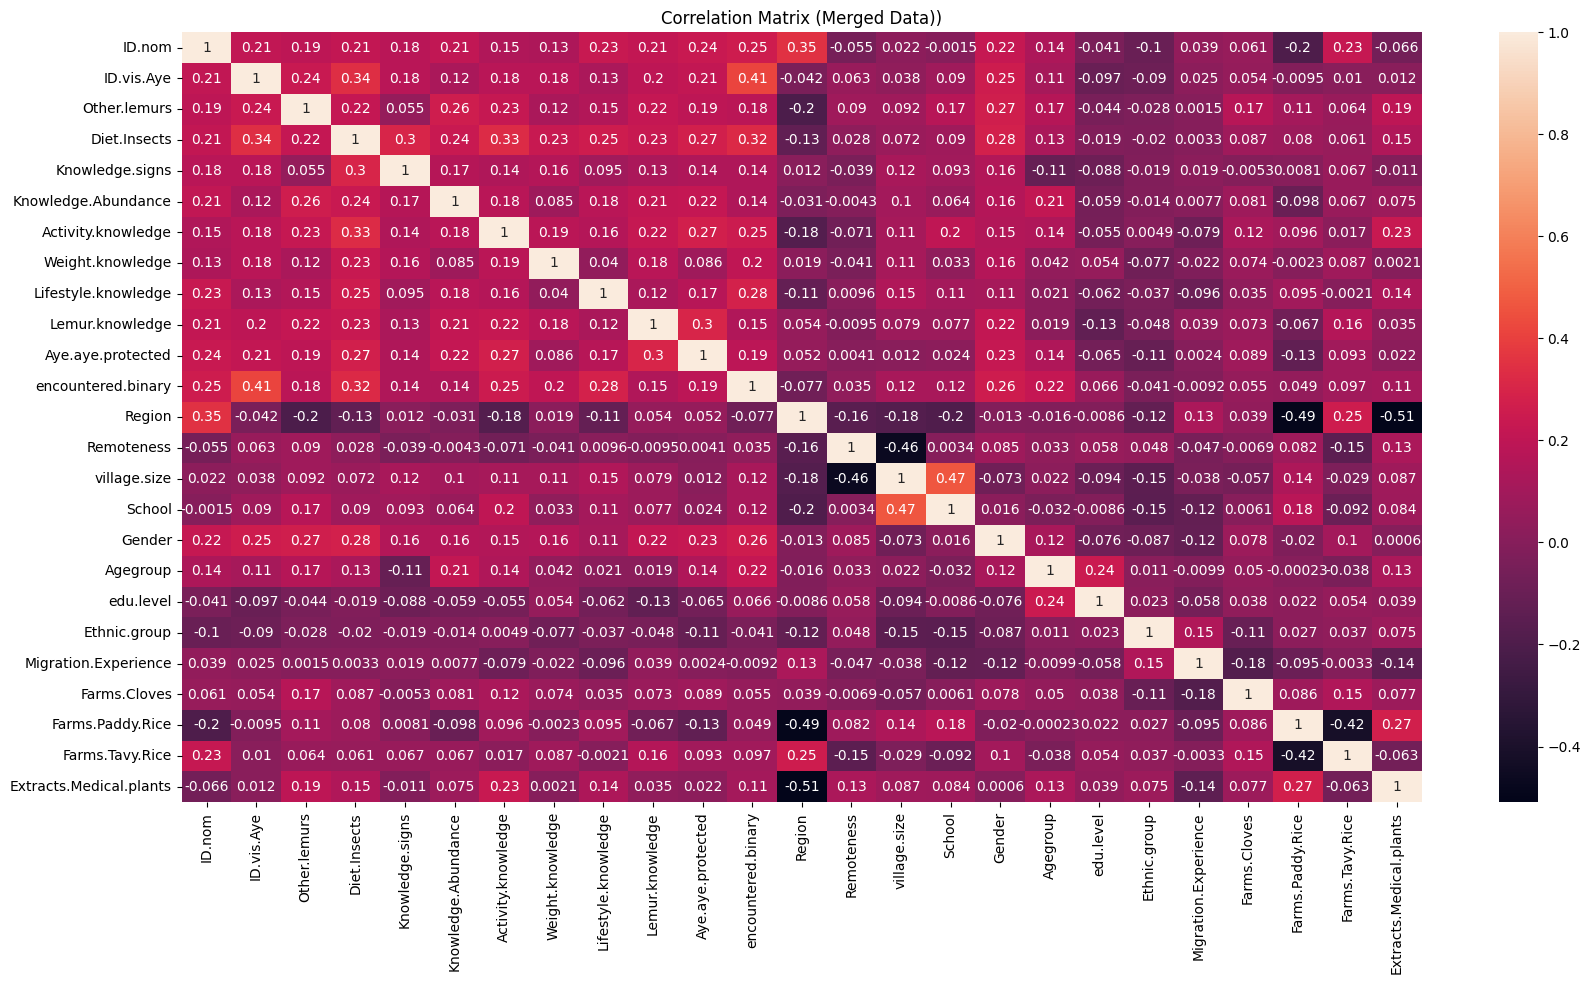

In [5]:
plt.figure(figsize=(20, 10))
sns.heatmap(merged_data.corr('spearman'), annot=True)
plt.title("Correlation Matrix (Merged Data))")
plt.show()

In [6]:
# Data Preprocessing for Binary-Only Dataset (No Categorical Encoding)
X_binary = data_binary.drop('Clove.benefit.score', axis=1)
y_binary = data_binary['Clove.benefit.score']

# Train-test split for the binary dataset
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)


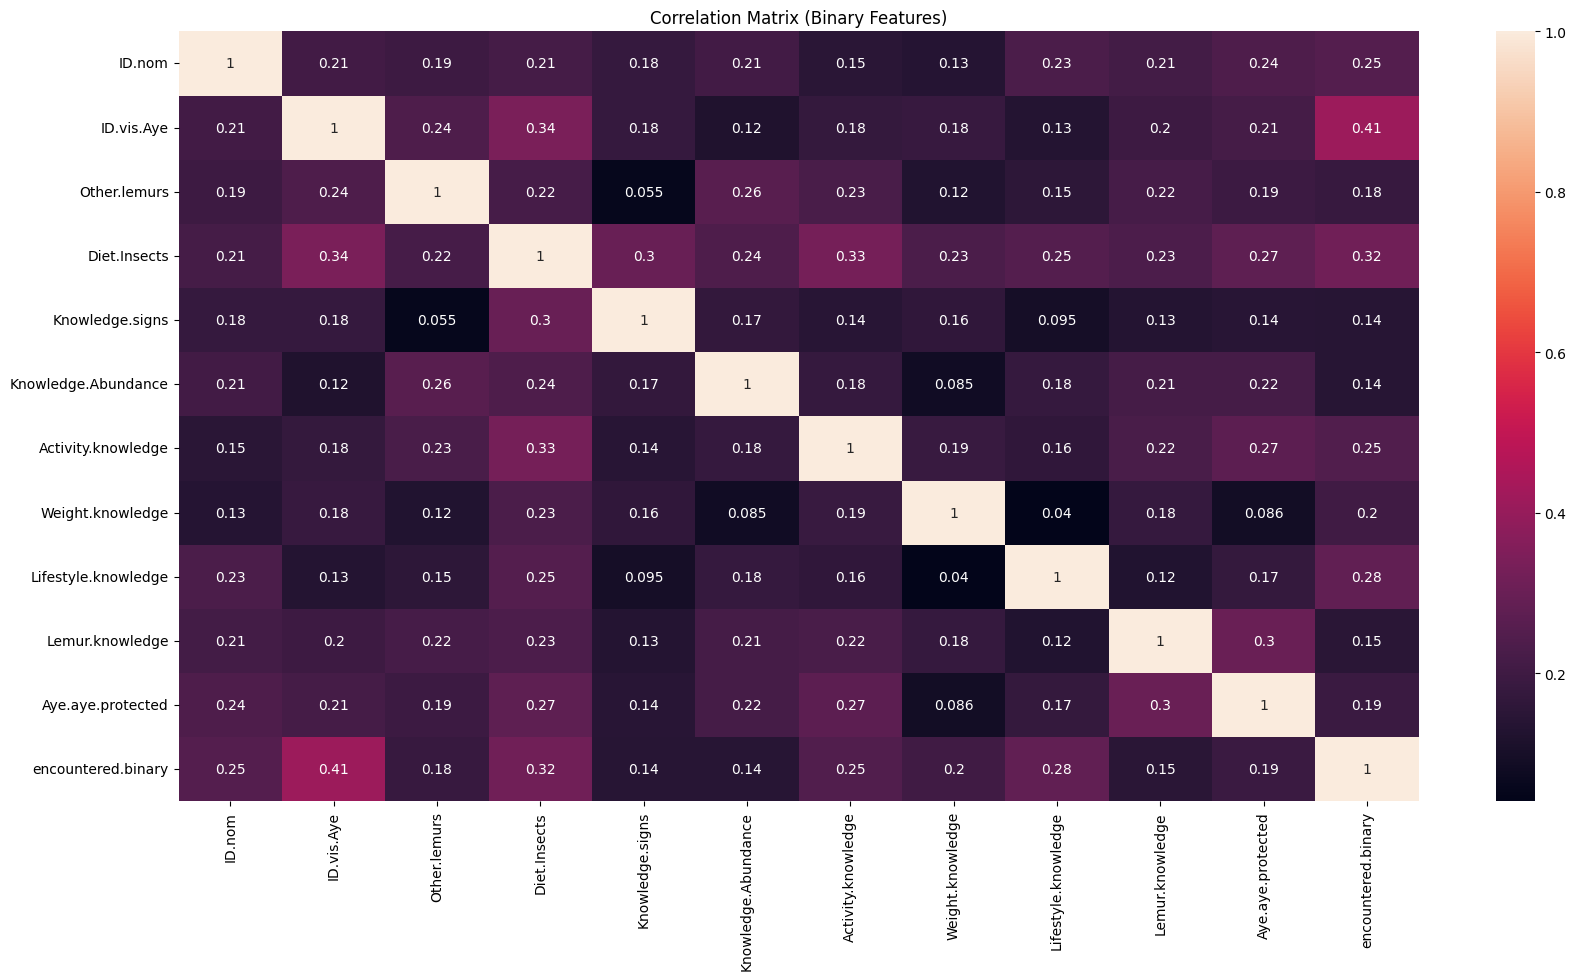

In [7]:
plt.figure(figsize=(20, 10))
sns.heatmap(X_binary.corr('pearson'), annot=True)
plt.title("Correlation Matrix (Binary Features)")
plt.show()

### Choosing Micro-Averaged Jaccard Score for Feature Importance
To assess feature importance in this analysis, we use the **micro-averaged Jaccard score**. This metric is more suitable because it considers each individual instance's performance, providing a more granular view of how features contribute to the model's predictions. The micro-averaged approach is particularly useful when we aim to prioritize the model's ability to handle each instance equally, without being biased towards any particular class. As our goal is to uncover which features have the most impact across all instances, the micro-averaged Jaccard score will give a balanced measure of feature importance, aligning with our analysis objectives.


                Feature  Jaccard_Score
3          Diet.Insects       0.540275
1            ID.vis.Aye       0.476460
6    Activity.knowledge       0.465421
11   encountered.binary       0.441176
7      Weight.knowledge       0.435897
2          Other.lemurs       0.430657
9       Lemur.knowledge       0.422868
4       Knowledge.signs       0.417722
5   Knowledge.Abundance       0.415162
10    Aye.aye.protected       0.415162
8   Lifestyle.knowledge       0.407540
0                ID.nom       0.368237




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



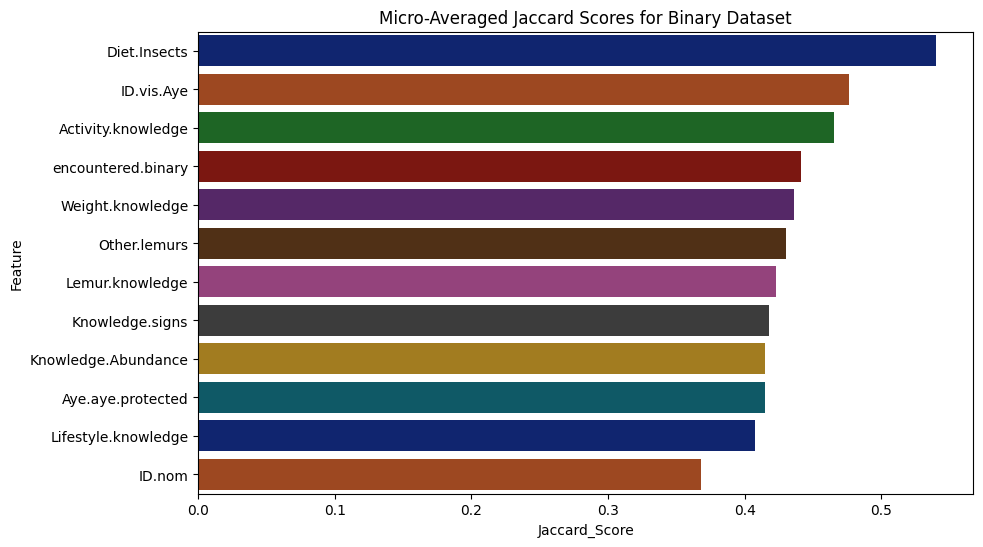

In [8]:
# Micro-Averaged Jaccard Correlation for Binary-Only Dataset
from sklearn.metrics import jaccard_score

# Compute Jaccard scores using micro-averaging
jaccard_scores_binary_micro = {}
for column in X_binary.columns:
    try:
        score = jaccard_score(y_binary, X_binary[column], average='micro')
        jaccard_scores_binary_micro[column] = score
    except ValueError:
        continue

jaccard_df_binary_micro = pd.DataFrame(list(jaccard_scores_binary_micro.items()), columns=['Feature', 'Jaccard_Score']).sort_values(by='Jaccard_Score', ascending=False)
print(jaccard_df_binary_micro)
plt.figure(figsize=(10, 6))
sns.barplot(x='Jaccard_Score', y='Feature', data=jaccard_df_binary_micro, palette='dark')
plt.title('Micro-Averaged Jaccard Scores for Binary Dataset')
plt.show()


### Chi-Square Feature Selection
Chi-square tests are used to determine the significance of the association between categorical variables. In this analysis, the chi-square test will help us identify the features that have the strongest relationship with the target variable ("Clove.Benefit.Score"). This step will further guide our feature selection process for building more robust models.


                Feature  Chi2 Score       p-value
3          Diet.Insects   36.877871  1.257653e-09
1            ID.vis.Aye   24.963978  5.841152e-07
6    Activity.knowledge   14.311917  1.548813e-04
11   encountered.binary   12.006680  5.301021e-04
7      Weight.knowledge    9.473615  2.084482e-03
2          Other.lemurs    9.053031  2.622597e-03
9       Lemur.knowledge    7.229094  7.173140e-03
10    Aye.aye.protected    7.077394  7.806248e-03
5   Knowledge.Abundance    5.905756  1.509149e-02
4       Knowledge.signs    5.766727  1.633242e-02
8   Lifestyle.knowledge    4.659131  3.088882e-02
0                ID.nom    2.316430  1.280135e-01




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



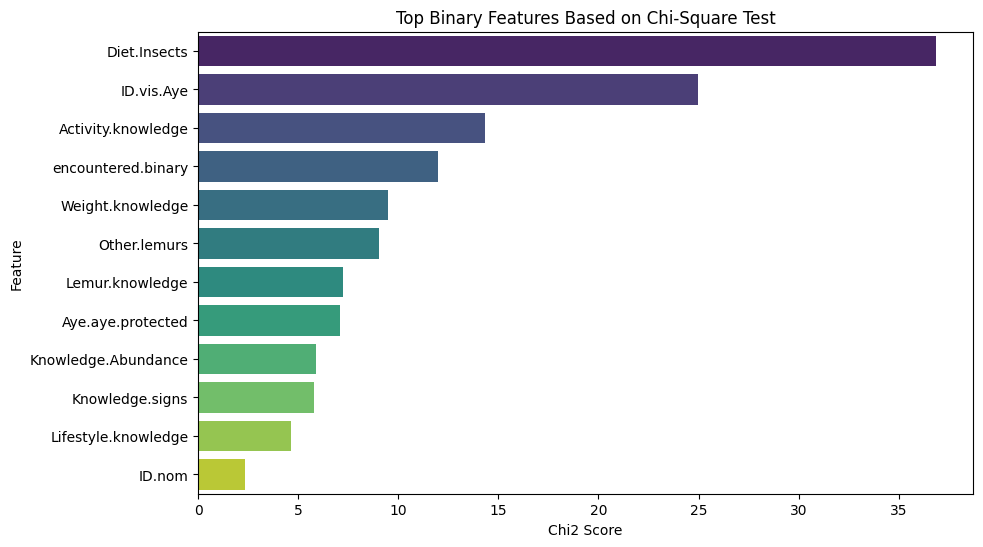

In [9]:
# Chi-Square Feature Selection for Binary Dataset
chi2_scores, p_values = chi2(X_binary, y_binary)

# Create a DataFrame to hold the feature names, chi-square scores, and p-values for binary dataset
chi2_df = pd.DataFrame({'Feature': X_binary.columns, 'Chi2 Score': chi2_scores, 'p-value': p_values}).sort_values(by='p-value', ascending=True)

print(chi2_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='Chi2 Score', y='Feature', data=chi2_df.head(15), palette='viridis')
plt.title('Top Binary Features Based on Chi-Square Test')
plt.show()


                    Feature  Chi2 Score       p-value
3              Diet.Insects   36.877871  1.257653e-09
1                ID.vis.Aye   24.963978  5.841152e-07
21                 Gender_1   15.737936  7.275040e-05
6        Activity.knowledge   14.311917  1.548813e-04
11       encountered.binary   12.006680  5.301021e-04
22                 Region_1    9.586589  1.960037e-03
7          Weight.knowledge    9.473615  2.084482e-03
2              Other.lemurs    9.053031  2.622597e-03
28               Agegroup_4    7.395812  6.537591e-03
9           Lemur.knowledge    7.229094  7.173140e-03
10        Aye.aye.protected    7.077394  7.806248e-03
20  Extracts.Medical.plants    6.997107  8.164157e-03
5       Knowledge.Abundance    5.905756  1.509149e-02
4           Knowledge.signs    5.766727  1.633242e-02
23                 Region_2    4.692930  3.028696e-02
8       Lifestyle.knowledge    4.659131  3.088882e-02
32              edu.level_2    3.005483  8.298322e-02
16     Migration.Experience 



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



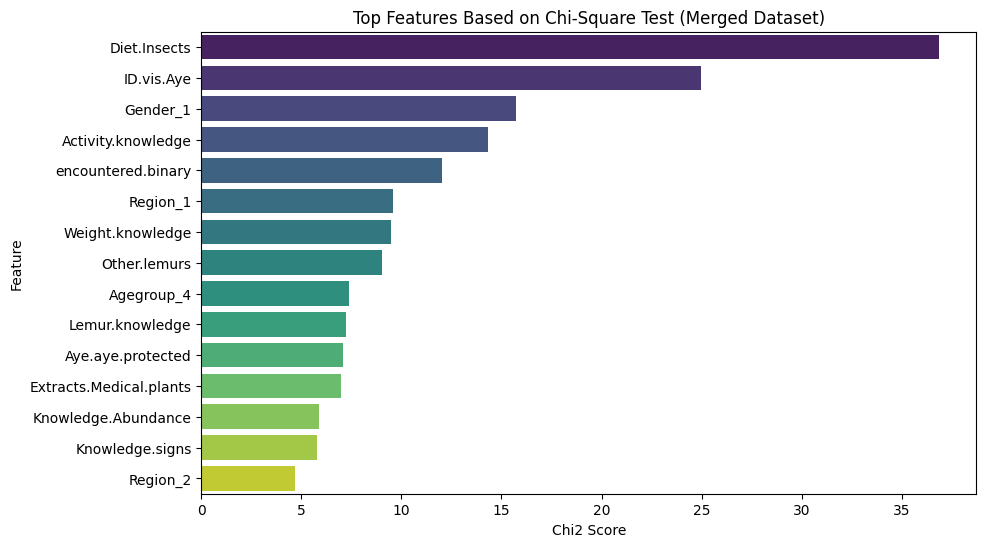

In [10]:
# Chi-Square Feature Selection for Merged Dataset
chi2_scores_merged, p_values_merged = chi2(X_merged_encoded, y_merged_encoded)
chi2_df_merged = pd.DataFrame({'Feature': X_merged_encoded.columns, 'Chi2 Score': chi2_scores_merged, 'p-value': p_values_merged}).sort_values(by='p-value', ascending=True)
print(chi2_df_merged)
plt.figure(figsize=(10, 6))
sns.barplot(x='Chi2 Score', y='Feature', data=chi2_df_merged.head(15), palette='viridis')
plt.title('Top Features Based on Chi-Square Test (Merged Dataset)')
plt.show()

In [11]:
# Multicollinearity Check using VIF (Merged Dataset)
vif_data_merged = pd.DataFrame()
vif_data_merged['Feature'] = X_merged.columns
vif_data_merged['VIF'] = [variance_inflation_factor(X_merged.values, i) for i in range(X_merged.shape[1])]

vif_threshold = 10

features_to_drop = vif_data_merged[vif_data_merged['VIF'] > vif_threshold]['Feature']
X_merged_reduced = X_merged.drop(features_to_drop, axis=1)

vif_data_merged_reduced = pd.DataFrame()
vif_data_merged_reduced['Feature'] = X_merged_reduced.columns
vif_data_merged_reduced['VIF'] = [variance_inflation_factor(X_merged_reduced.values, i) for i in range(X_merged_reduced.shape[1])]
print(vif_data_merged_reduced)
print(vif_data_merged_reduced.shape)


                    Feature       VIF
0                    ID.nom  4.644608
1                ID.vis.Aye  1.713941
2              Other.lemurs  4.785829
3              Diet.Insects  2.344825
4           Knowledge.signs  1.551458
5       Knowledge.Abundance  2.407225
6        Activity.knowledge  3.264589
7          Weight.knowledge  1.579063
8       Lifestyle.knowledge  2.161805
9           Lemur.knowledge  2.768507
10        Aye.aye.protected  4.791784
11       encountered.binary  1.773591
12                   School  2.966199
13         Forest.cover2017  4.620528
14         Forest.cover1990  5.523447
15                   Gender  3.726115
16                 Agegroup  3.419846
17                edu.level  4.705046
18             Ethnic.group  6.587283
19     Migration.Experience  1.433994
20         Farms.Paddy.Rice  3.171631
21          Farms.Tavy.Rice  3.878809
22  Extracts.Medical.plants  2.393624
(23, 2)


In [12]:
categorical_columns = ['Gender', 'Region', 'Agegroup', 'edu.level']  

merged_data_encoded = pd.get_dummies(X_merged, columns=categorical_columns, drop_first=True)
vif_data_encoded = pd.DataFrame()
vif_data_encoded['Feature'] = X_merged_encoded.columns
vif_data_encoded['VIF'] = [variance_inflation_factor(X_merged_encoded.values, i) for i in range(X_merged_encoded.shape[1])]

# VIF threshold
vif_threshold = 10
features_to_drop_encoded = vif_data_encoded[vif_data_encoded['VIF'] > vif_threshold]['Feature']
X_merged_encoded_reduced = X_merged_encoded.drop(features_to_drop_encoded, axis=1)
print(X_merged_encoded_reduced.columns)
print(y_merged_encoded)


Index(['ID.nom', 'ID.vis.Aye', 'Other.lemurs', 'Diet.Insects',
       'Knowledge.signs', 'Knowledge.Abundance', 'Activity.knowledge',
       'Weight.knowledge', 'Lifestyle.knowledge', 'Lemur.knowledge',
       'Aye.aye.protected', 'encountered.binary', 'School', 'Ethnic.group',
       'Migration.Experience', 'Farms.Paddy.Rice', 'Farms.Tavy.Rice',
       'Extracts.Medical.plants', 'Gender_1', 'Agegroup_1', 'Agegroup_2',
       'Agegroup_3', 'Agegroup_4', 'Agegroup_5', 'Agegroup_6', 'edu.level_1',
       'edu.level_2', 'edu.level_3'],
      dtype='object')
0      1
1      1
2      1
3      1
4      0
      ..
387    1
388    0
389    1
390    1
391    1
Name: Clove.benefit.score, Length: 392, dtype: int64


### Model Training and Evaluation
- Train Logistic Regression, Random Forest, and XGBoost models.
- Perform hyperparameter tuning using GridSearchCV for XGBoost.
- Evaluate models using accuracy, precision, recall, and F1-score.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_merged_encoded_reduced, y_merged_encoded, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_performances = {}

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
model_performances['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg)
}
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logreg))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)
model_performances['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)  
y_pred_xgb = xgb.predict(X_test)
model_performances['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb)
}
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

print("\nModel Performance Summary:")
for model, scores in model_performances.items():
    print(f"{model}:")
    for metric, score in scores.items():
        print(f"  {metric}: {score:.4f}")

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.62      0.75      0.68        60
           1       0.67      0.53      0.60        58

    accuracy                           0.64       118
   macro avg       0.65      0.64      0.64       118
weighted avg       0.65      0.64      0.64       118

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.69      0.87      0.77        60
           1       0.81      0.60      0.69        58

    accuracy                           0.74       118
   macro avg       0.75      0.74      0.73       118
weighted avg       0.75      0.74      0.73       118

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.61      0.83      0.70        60
           1       0.72      0.45      0.55        58

    accuracy                           0.64       118
   macro avg       0.67      0.64      0.63    

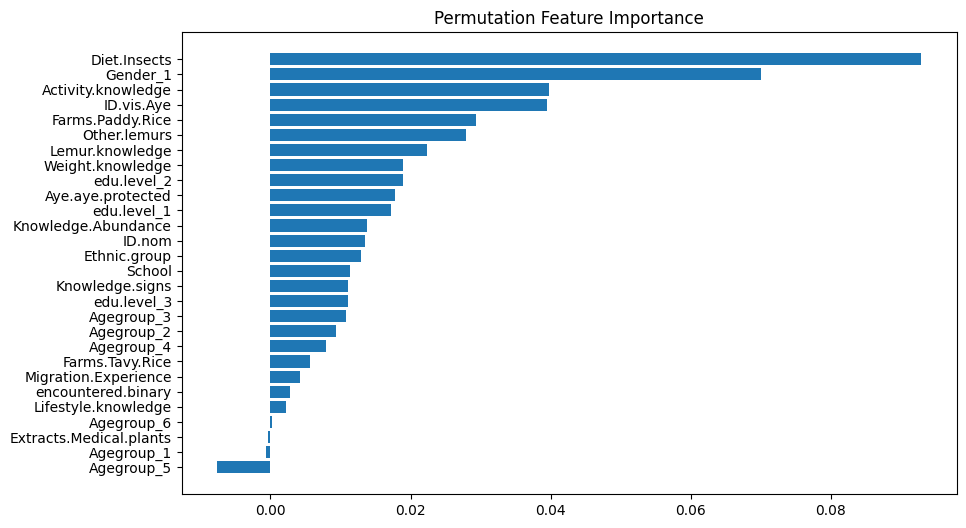

In [14]:
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
features = X_test.columns
importances = perm_importance.importances_mean

# Sort features by importance
sorted_indices = importances.argsort()
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [features[i] for i in sorted_indices])
plt.title('Permutation Feature Importance')
plt.show()

In [ ]:
# low_importance_features = [features[i] for i in range(len(importances)) if importances[i] < 0.001]
# X_train_hi = X_train.drop(low_importance_features, axis=1)
# X_test_hi = X_test.drop(low_importance_features, axis=1)
# rf_reduced = RandomForestClassifier(n_estimators=50, max_depth=None, min_samples_split=10, random_state=42)
# rf_reduced.fit(X_train_hi, y_train)
# y_pred_reduced = rf_reduced.predict(X_test_hi)
# accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
# print(f"Accuracy after removing low-importance features: {accuracy_reduced}")
# print(low_importance_features)

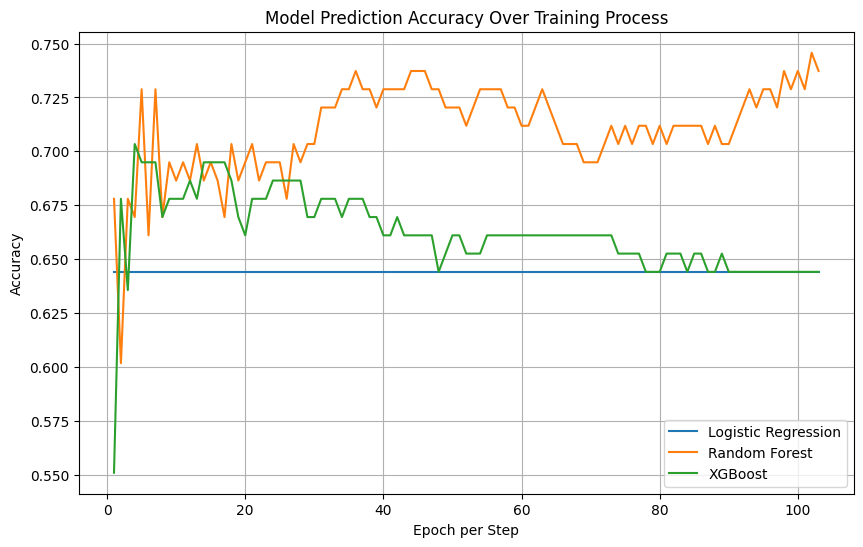

In [15]:
accuracy_plot_data = {
    'Epoch': [],
    'Model': [],
    'Accuracy': []
}

# Scale the data before model training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def record_accuracy(model_name, X_train, X_test, y_train, y_test):
    if model_name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, solver='lbfgs')
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif model_name == 'XGBoost':
        model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    
    # Simulating 104 steps of training 
    for i in range(1, 104):  
        if model_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, solver='lbfgs')
            model.fit(X_train_scaled, y_train)  
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(n_estimators=i, random_state=42)
            model.fit(X_train, y_train)
        elif model_name == 'XGBoost':
            model = XGBClassifier(n_estimators=i, use_label_encoder=False, eval_metric='logloss', random_state=42)
            model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test_scaled if model_name == 'Logistic Regression' else X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Record accuracy for plotting
        accuracy_plot_data['Epoch'].append(i)
        accuracy_plot_data['Model'].append(model_name)
        accuracy_plot_data['Accuracy'].append(accuracy)

# Record accuracies for each model
record_accuracy('Logistic Regression', X_train_scaled, X_test_scaled, y_train, y_test)
record_accuracy('Random Forest', X_train, X_test, y_train, y_test)
record_accuracy('XGBoost', X_train, X_test, y_train, y_test)
plt.figure(figsize=(10, 6))
for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    model_data = [accuracy_plot_data['Accuracy'][i] for i in range(len(accuracy_plot_data['Accuracy'])) if accuracy_plot_data['Model'][i] == model_name]
    plt.plot(range(1, 104), model_data, label=model_name)

plt.title('Model Prediction Accuracy Over Training Process')
plt.xlabel('Epoch per Step')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### SHAP Explainer for Random Forest Model

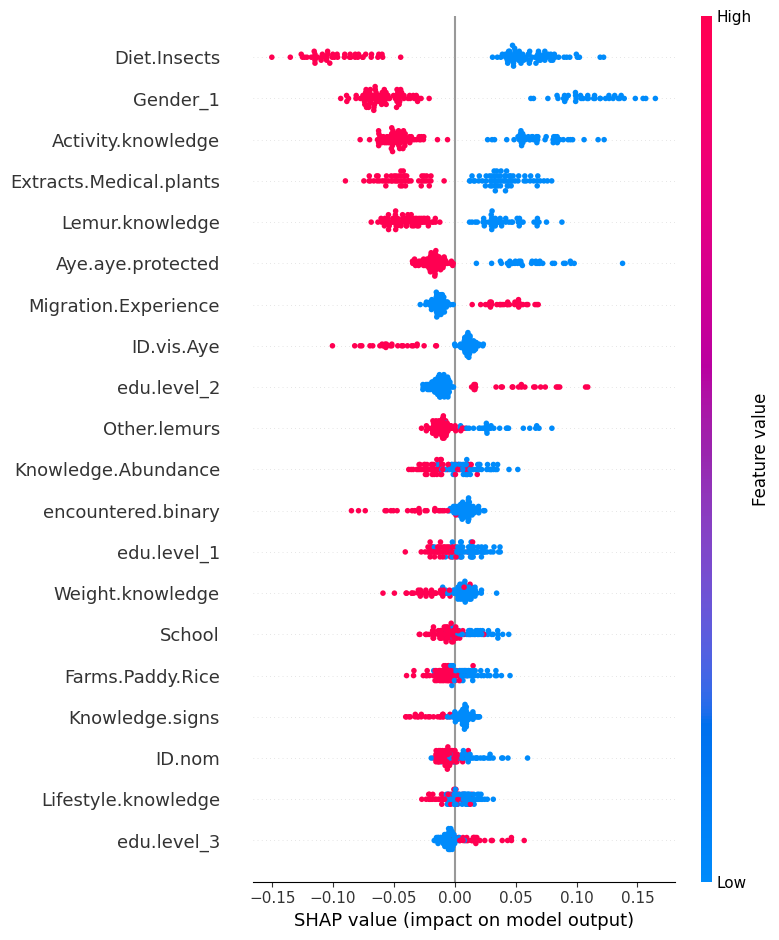

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) 
explainer = shap.TreeExplainer(rf)
# SHAP values for the test set
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(20, 15))
shap.summary_plot(shap_values[1], X_test)  #SHAP values for Class 1